# Análisis de Emisiones GHG y Huella de Carbono
## Colombia en el Contexto Latinoamericano — Metodología GHG Protocol

**Dataset:** Our World in Data CO2 and Greenhouse Gas Emissions  
**Fuente:** Hannah Ritchie, Pablo Rosado & Max Roser (2023). *CO₂ and Greenhouse Gas Emissions*. Our World in Data. https://ourworldindata.org/co2-and-greenhouse-gas-emissions  
**Autora:** Wendy J. Hernández  
**Perfil:** Ingeniería Química · Especialización Ambiental · Data Analytics  
**GitHub:** github.com/wjhernandez

---

## Contexto

El cambio climático es el desafío ambiental más urgente del siglo XXI. El seguimiento y reporte de emisiones de GHG (Greenhouse Gas. Gases de Efecto Invernadero) es el primer paso para cualquier estrategia de descarbonización empresarial o nacional. El estándar internacional más utilizado para este propósito es el **GHG Protocol (Greenhouse Gas Protocol — Protocolo de Gases de Efecto Invernadero)**, desarrollado por el World Resources Institute (WRI) y el World Business Council for Sustainable Development (WBCSD).

Colombia se comprometió bajo el Acuerdo de París a reducir sus emisiones GHG en un **51% para 2030** respecto al escenario tendencial, uno de los compromisos NDC (Nationally Determined Contributions Contribuciones Determinadas a Nivel Nacional) más ambiciosos de América Latina.

### Preguntas de análisis

> 1. ¿Cuál es la tendencia histórica de emisiones de CO2 en Colombia y cómo se compara con la región latinoamericana?
> 2. ¿Qué factores explican la intensidad de carbono de Colombia (emisiones por unidad de PIB)?
> 3. ¿Está Colombia en trayectoria para cumplir su NDC al 2030?
> 4. ¿Cómo se distribuyen las emisiones per cápita entre los países de la región?

---
## 0. Configuración del Entorno

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Paleta de colores con identidad ambiental
PALETTE = {
    'colombia':     '#2d7d9a',
    'latam':        '#f4a261',
    'mundo':        '#e63946',
    'verde':        '#52b788',
    'alerta':       '#e63946',
    'neutro':       '#adb5bd'
}

# Países de América Latina para comparación regional
LATAM = [
    'Colombia', 'Brazil', 'Mexico', 'Argentina', 'Chile',
    'Peru', 'Ecuador', 'Venezuela', 'Bolivia', 'Paraguay',
    'Uruguay', 'Costa Rica', 'Panama', 'Guatemala', 'Honduras'
]

print('Entorno configurado correctamente.')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__}')

Entorno configurado correctamente.
Pandas: 2.2.3 | NumPy: 2.1.3


---
## 1. Carga y Exploración del Dataset

El dataset de Our World in Data (OWID) es la fuente de referencia global para datos de emisiones GHG. Integra datos del Global Carbon Project, Climate Watch, BP Statistical Review y otras fuentes primarias. Se actualiza anualmente y es ampliamente citado por el IPCC (Intergovernmental Panel on Climate Change Panel Intergubernamental sobre Cambio Climático) y organismos internacionales.

In [29]:
import os

# CARGA DEL DATASET — OWID CO2 and Greenhouse Gas Emissions
# Actualizado con Global Carbon Budget 2024 (datos hasta 2023)
# Fuente: Ritchie, H., Rosado, P. & Roser, M. (2023). Our World in Data.


# INSTRUCCIONES DE DESCARGA:
# 1. Ve a este link en tu navegador y descarga el archivo:
#    https://github.com/owid/co2-data/blob/master/owid-co2-data.csv
#    Haz clic en el botón "Download raw file" (ícono de descarga)
# 2. Guarda el archivo en la misma carpeta donde está este notebook
# 3. Ejecuta esta celda

ARCHIVO_LOCAL = 'owid-co2-data.csv'

# Verificación de existencia del archivo
if not os.path.exists(ARCHIVO_LOCAL):
    print(f'ERROR: No se encuentra el archivo {ARCHIVO_LOCAL}')
    print()
    print('Descárgalo desde:')
    print('  https://github.com/owid/co2-data/blob/master/owid-co2-data.csv')
    print('  Clic en "Download raw file" y guárdalo en esta carpeta.')
else:
    df_raw = pd.read_csv(ARCHIVO_LOCAL)
    print('=== DIMENSIONES DEL DATASET ===')
    print(f'Registros: {df_raw.shape[0]:,}   |   Variables: {df_raw.shape[1]}')
    print(f'Período: {df_raw["year"].min()} — {df_raw["year"].max()}')
    print(f'Países/Regiones: {df_raw["country"].nunique()}')
    print()
    print('=== PRIMERAS 5 FILAS ===')
    print(df_raw.head())

=== DIMENSIONES DEL DATASET ===
Registros: 50,411   |   Variables: 79
Período: 1750 — 2024
Países/Regiones: 254

=== PRIMERAS 5 FILAS ===
       country  year iso_code  population  gdp  cement_co2  \
0  Afghanistan  1750      AFG   2802560.0  NaN         0.0   
1  Afghanistan  1751      AFG         NaN  NaN         0.0   
2  Afghanistan  1752      AFG         NaN  NaN         0.0   
3  Afghanistan  1753      AFG         NaN  NaN         0.0   
4  Afghanistan  1754      AFG         NaN  NaN         0.0   

   cement_co2_per_capita  co2  co2_growth_abs  co2_growth_prct  ...  \
0                    0.0  NaN             NaN              NaN  ...   
1                    NaN  NaN             NaN              NaN  ...   
2                    NaN  NaN             NaN              NaN  ...   
3                    NaN  NaN             NaN              NaN  ...   
4                    NaN  NaN             NaN              NaN  ...   

   share_global_other_co2  share_of_temperature_change_from_gh

In [30]:
# Diccionario de variables clave

variables_clave = {
    'country':            'País o región',
    'year':               'Año',
    'co2':                'Emisiones CO2 totales (MtCO2 — megatoneladas de CO2)',
    'co2_per_capita':     'Emisiones CO2 per cápita (tCO2/habitante)',
    'co2_per_gdp':        'Intensidad de carbono (kgCO2 por USD de PIB)',
    'coal_co2':           'Emisiones CO2 por carbón (MtCO2)',
    'oil_co2':            'Emisiones CO2 por petróleo (MtCO2)',
    'gas_co2':            'Emisiones CO2 por gas natural (MtCO2)',
    'cement_co2':         'Emisiones CO2 por cemento (MtCO2)',
    'methane':            'Emisiones CH4 (metano) (MtCO2eq)',
    'nitrous_oxide':      'Emisiones N2O (óxido nitroso) (MtCO2eq)',
    'total_ghg':          'Emisiones totales GHG (Greenhouse Gas) (MtCO2eq)',
    'energy_per_capita':  'Consumo energético per cápita (kWh/habitante)',
    'share_global_co2':   'Participación en emisiones globales (%)',
    'cumulative_co2':     'Emisiones CO2 acumuladas históricas (MtCO2)',
    'population':         'Población',
    'gdp':                'PIB en USD constantes 2011 (PPP)'
}

print('=== VARIABLES CLAVE DEL DATASET ===')
for var, desc in variables_clave.items():
    disponible = 'OK' if var in df_raw.columns else 'NO DISPONIBLE'
    print(f'  [{disponible}]  {var:<30} {desc}')

=== VARIABLES CLAVE DEL DATASET ===
  [OK]  country                        País o región
  [OK]  year                           Año
  [OK]  co2                            Emisiones CO2 totales (MtCO2 — megatoneladas de CO2)
  [OK]  co2_per_capita                 Emisiones CO2 per cápita (tCO2/habitante)
  [OK]  co2_per_gdp                    Intensidad de carbono (kgCO2 por USD de PIB)
  [OK]  coal_co2                       Emisiones CO2 por carbón (MtCO2)
  [OK]  oil_co2                        Emisiones CO2 por petróleo (MtCO2)
  [OK]  gas_co2                        Emisiones CO2 por gas natural (MtCO2)
  [OK]  cement_co2                     Emisiones CO2 por cemento (MtCO2)
  [OK]  methane                        Emisiones CH4 (metano) (MtCO2eq)
  [OK]  nitrous_oxide                  Emisiones N2O (óxido nitroso) (MtCO2eq)
  [OK]  total_ghg                      Emisiones totales GHG (Greenhouse Gas) (MtCO2eq)
  [OK]  energy_per_capita              Consumo energético per cápita (kWh/ha

In [31]:
# Filtro: período moderno (1990-2022) y países de interés
AÑO_INICIO = 1990
AÑO_FIN = 2022

df = df_raw[
    (df_raw['year'] >= AÑO_INICIO) &
    (df_raw['year'] <= AÑO_FIN) &
    (df_raw['country'].isin(LATAM + ['World']))
].copy()

# Dataset específico de Colombia
df_col = df[df['country'] == 'Colombia'].copy()

# Dataset de América Latina sin Colombia
df_latam = df[df['country'].isin(LATAM)].copy()

print(f'Registros filtrados: {df.shape[0]:,}')
print(f'Período: {AÑO_INICIO} — {AÑO_FIN}')
print(f'Colombia — registros disponibles: {df_col.shape[0]}')
print()
print('Variables con datos para Colombia:')
nulos_col = df_col[list(variables_clave.keys())].isnull().sum()
print(nulos_col[nulos_col < len(df_col)].to_string())

Registros filtrados: 528
Período: 1990 — 2022
Colombia — registros disponibles: 33

Variables con datos para Colombia:
country              0
year                 0
co2                  0
co2_per_capita       0
co2_per_gdp          0
coal_co2             0
oil_co2              0
gas_co2              0
cement_co2           0
methane              0
nitrous_oxide        0
total_ghg            0
energy_per_capita    0
share_global_co2     0
cumulative_co2       0
population           0
gdp                  0


---
## 2. Análisis Exploratorio Tendencia Histórica de Emisiones

El análisis de tendencias históricas es el punto de partida de cualquier inventario GHG (Greenhouse Gas  Gases de Efecto Invernadero). Permite identificar patrones, quiebres de tendencia y la velocidad de cambio en las emisiones información esencial para establecer líneas base y evaluar el impacto de políticas ambientales.

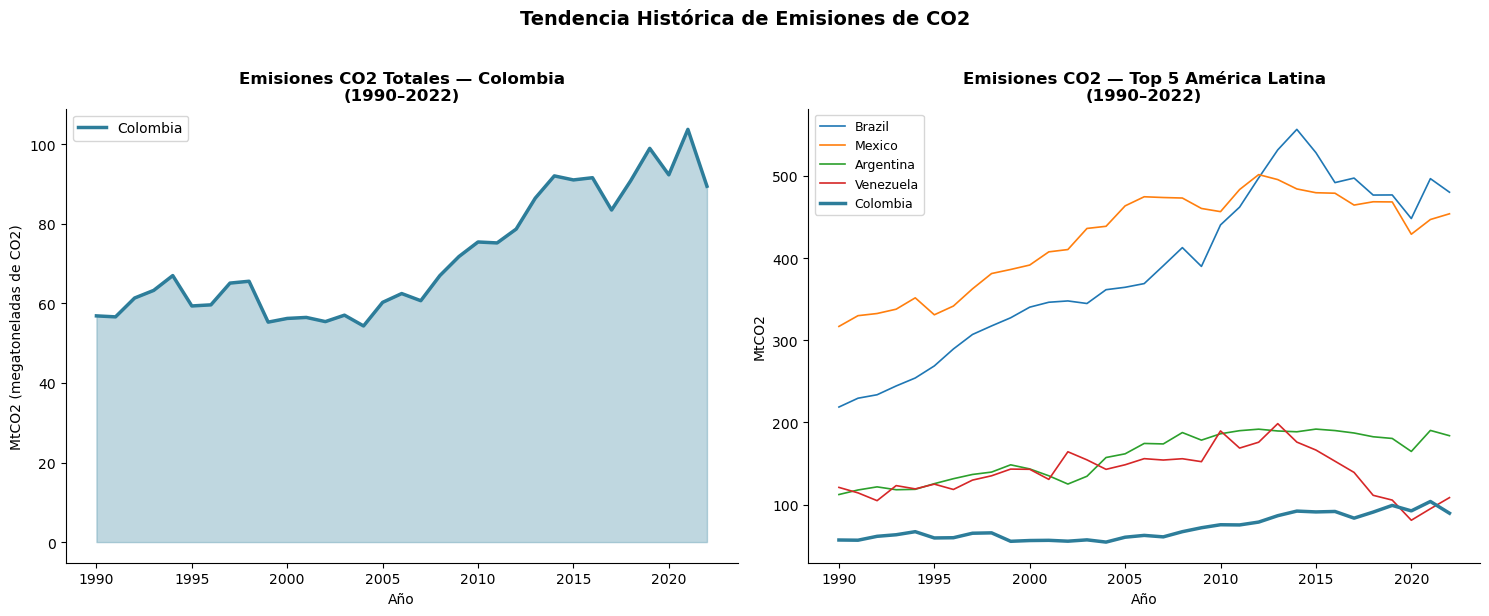

Colombia — Emisiones CO2:
  1990: 56.9 MtCO2
  2022: 89.4 MtCO2
  Crecimiento 1990-2022: 57.3%


In [10]:
# 2.1 Tendencia de emisiones CO2 totales — Colombia 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Emisiones totales CO2 Colombia
axes[0].fill_between(df_col['year'], df_col['co2'],
                     alpha=0.3, color=PALETTE['colombia'])
axes[0].plot(df_col['year'], df_col['co2'],
             color=PALETTE['colombia'], linewidth=2.5, label='Colombia')
axes[0].set_title('Emisiones CO2 Totales — Colombia\n(1990–2022)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('MtCO2 (megatoneladas de CO2)')
axes[0].legend()

# Comparación regional: top 5 países LATAM por emisiones 2022
top5_latam = df_latam[df_latam['year'] == 2022].nlargest(5, 'co2')['country'].tolist()
colors_top5 = [PALETTE['colombia'] if c == 'Colombia' else PALETTE['neutro'] for c in top5_latam]

for i, pais in enumerate(top5_latam):
    subset = df_latam[df_latam['country'] == pais]
    color = PALETTE['colombia'] if pais == 'Colombia' else f'C{i}'
    lw = 2.5 if pais == 'Colombia' else 1.2
    axes[1].plot(subset['year'], subset['co2'],
                 label=pais, linewidth=lw, color=color)

axes[1].set_title('Emisiones CO2 — Top 5 América Latina\n(1990–2022)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('MtCO2')
axes[1].legend(fontsize=9)

plt.suptitle('Tendencia Histórica de Emisiones de CO2',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_tendencia_co2.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadísticas clave
co2_1990 = df_col[df_col['year'] == 1990]['co2'].values[0]
co2_2022 = df_col[df_col['year'] == 2022]['co2'].values[0]
crecimiento = (co2_2022 - co2_1990) / co2_1990 * 100
print(f'Colombia — Emisiones CO2:')
print(f'  1990: {co2_1990:.1f} MtCO2')
print(f'  2022: {co2_2022:.1f} MtCO2')
print(f'  Crecimiento 1990-2022: {crecimiento:.1f}%')

### Tendencia Histórica de Emisiones CO2 Colombia y América Latina

Las emisiones de CO2 de Colombia crecieron un 57.3% entre 1990 (56.9 MtCO2)
y 2022 (89.4 MtCO2), con tres fases diferenciadas: estabilización en los 90,
crecimiento acelerado entre 2005-2019, y caída por la pandemia COVID-19 en
2020 con recuperación parcial hacia 2022.

En el contexto regional, Colombia es el menor emisor del Top 5 de América
Latina, muy por debajo de Brazil y Mexico que dominan por tamaño económico.
Venezuela muestra una caída pronunciada desde 2013 consistente con su
contracción económica. Argentina mantiene una tendencia relativamente estable.

La caída pandémica de 2020 genera una base más baja para el cálculo de la
reducción requerida hacia la meta NDC (Nationally Determined Contributions —
Contribuciones Determinadas a Nivel Nacional) del 51% al 2030.

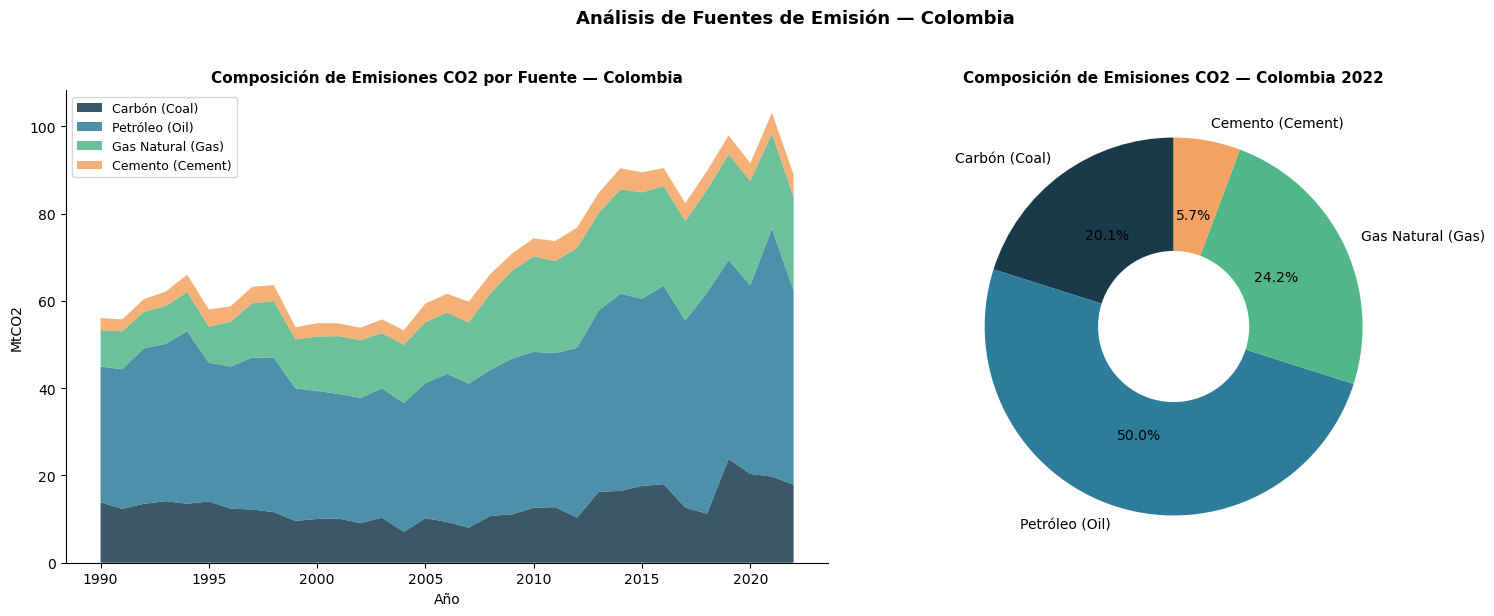

In [32]:
#  2.2 Composición de emisiones por fuente — Colombia 
fuentes = ['coal_co2', 'oil_co2', 'gas_co2', 'cement_co2']
fuentes_labels = [
    'Carbón (Coal)',
    'Petróleo (Oil)',
    'Gas Natural (Gas)',
    'Cemento (Cement)'
]
colores_fuentes = ['#1a3a4a', '#2d7d9a', '#52b788', '#f4a261']

df_col_fuentes = df_col[['year'] + fuentes].dropna().copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de área apilada — composición histórica
axes[0].stackplot(
    df_col_fuentes['year'],
    [df_col_fuentes[f] for f in fuentes],
    labels=fuentes_labels,
    colors=colores_fuentes,
    alpha=0.85
)
axes[0].set_title('Composición de Emisiones CO2 por Fuente — Colombia',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('MtCO2')
axes[0].legend(loc='upper left', fontsize=9)

# Gráfico de dona — composición 2022
datos_2022 = df_col[df_col['year'] == 2022][fuentes].values[0]
datos_2022_clean = [max(0, v) for v in datos_2022]
wedges, texts, autotexts = axes[1].pie(
    datos_2022_clean,
    labels=fuentes_labels,
    colors=colores_fuentes,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.6)
)
axes[1].set_title('Composición de Emisiones CO2 — Colombia 2022',
                  fontsize=11, fontweight='bold')

plt.suptitle('Análisis de Fuentes de Emisión — Colombia',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_composicion_fuentes.png', dpi=150, bbox_inches='tight')
plt.show()

### Composición de Emisiones CO2 por Fuente — Colombia

El GHG Protocol (Greenhouse Gas Protocol Protocolo de Gases de Efecto
Invernadero) clasifica las emisiones de CO2 por la fuente de origen del
carbono liberado. Estas cuatro fuentes cubren prácticamente el 100% de
las emisiones de CO2 fósil porque son los únicos reservorios donde el
carbono almacenado durante millones de años en el subsuelo se libera a
la atmósfera de forma masiva y cuantificable:

- **Carbón (Coal):** combustión en plantas termoeléctricas y procesos
  industriales de alta temperatura.
- **Petróleo (Oil):** combustión principalmente en el sector transporte
  — automóviles, camiones, aviones y embarcaciones.
- **Gas Natural (Gas):** combustión en generación eléctrica, industria
  y uso residencial.
- **Cemento (Cement):** proceso químico de calcinación
  (CaCO3 → CaO + CO2), independiente del combustible usado.

En Colombia 2022, el petróleo (Oil) concentra el 50% del total de
emisiones señalando al sector transporte como la palanca de reducción
más crítica para cumplir la meta NDC (Nationally Determined Contributions Contribuciones Determinadas a Nivel Nacional) del 51% al 2030.

Nota: las emisiones por deforestación y cambio de uso del suelo, también
significativas en Colombia, se reportan en una categoría separada del
inventario nacional y no están incluidas en esta figura.

---
## 3. Intensidad de Carbono y Emisiones Per Cápita

La **intensidad de carbono** (CO2 por unidad de PIB Producto Interno Bruto) es el indicador que usa el GHG Protocol para medir la eficiencia de una economía en términos de emisiones. Una economía puede crecer en emisiones absolutas pero mejorar su intensidad de carbono si su economía crece más rápido que sus emisiones.

Las **emisiones per cápita** son el indicador de equidad climática permiten comparar la responsabilidad individual de cada ciudadano en el total de emisiones globales, independientemente del tamaño del país.

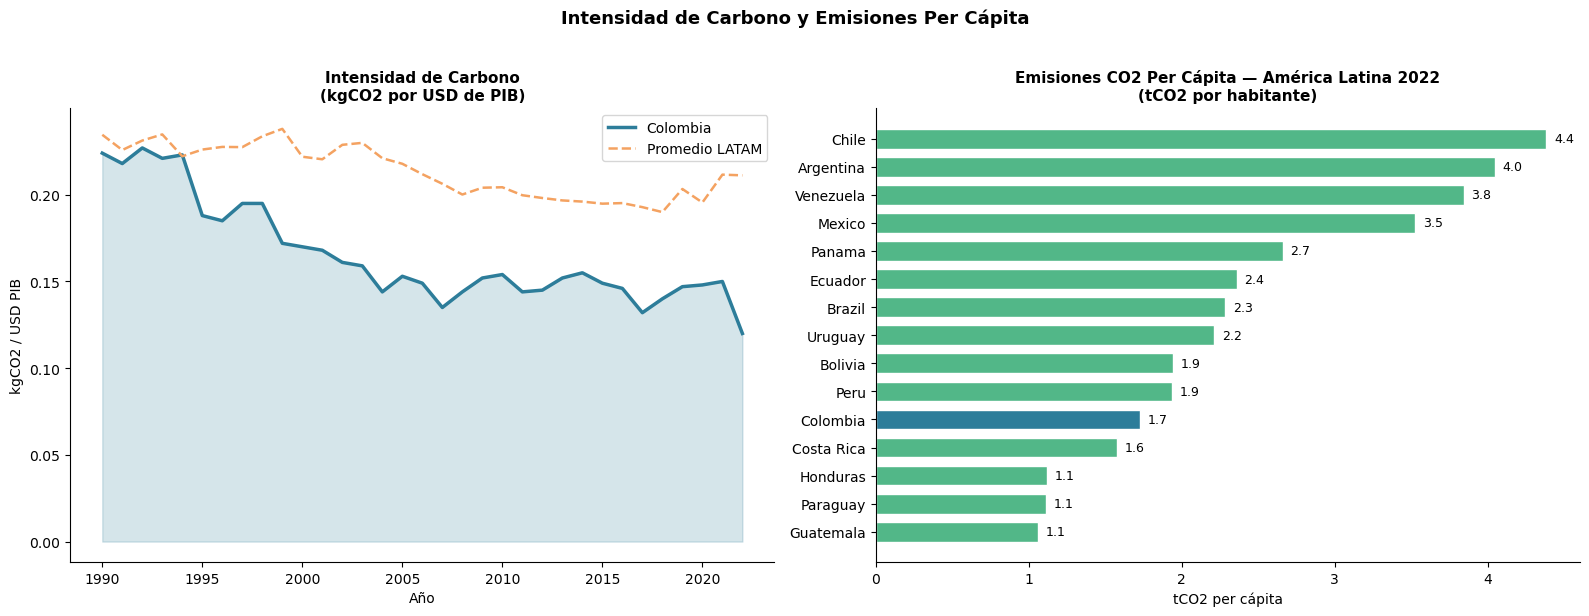

In [33]:
# 3.1 Intensidad de carbono — Colombia vs LATAM 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Intensidad de carbono Colombia
axes[0].plot(df_col['year'], df_col['co2_per_gdp'],
             color=PALETTE['colombia'], linewidth=2.5, label='Colombia')
axes[0].fill_between(df_col['year'], df_col['co2_per_gdp'],
                     alpha=0.2, color=PALETTE['colombia'])

# Promedio LATAM
latam_avg = df_latam.groupby('year')['co2_per_gdp'].mean().reset_index()
axes[0].plot(latam_avg['year'], latam_avg['co2_per_gdp'],
             color=PALETTE['latam'], linewidth=1.8,
             linestyle='--', label='Promedio LATAM')

axes[0].set_title('Intensidad de Carbono\n(kgCO2 por USD de PIB)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('kgCO2 / USD PIB')
axes[0].legend()

# Emisiones per cápita — comparación regional 2022
latam_2022 = df_latam[df_latam['year'] == 2022][['country', 'co2_per_capita']].dropna()
latam_2022 = latam_2022.sort_values('co2_per_capita', ascending=True)
colors_bar = [PALETTE['colombia'] if c == 'Colombia'
              else PALETTE['verde'] for c in latam_2022['country']]

bars = axes[1].barh(latam_2022['country'], latam_2022['co2_per_capita'],
                    color=colors_bar, edgecolor='white', height=0.7)
for bar, val in zip(bars, latam_2022['co2_per_capita']):
    axes[1].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=9)

axes[1].set_title('Emisiones CO2 Per Cápita — América Latina 2022\n(tCO2 por habitante)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('tCO2 per cápita')

plt.suptitle('Intensidad de Carbono y Emisiones Per Cápita',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_intensidad_percapita.png', dpi=150, bbox_inches='tight')
plt.show()

### Intensidad de Carbono y Emisiones Per Cápita

**Intensidad de carbono (kgCO2 por USD de PIB)**

La intensidad de carbono mide cuánto CO2 emite una economía por cada
dólar de PIB (Producto Interno Bruto) generado es el indicador de
eficiencia climática del GHG Protocol (Greenhouse Gas Protocol
Protocolo de Gases de Efecto Invernadero).

Colombia redujo su intensidad de 0.22 a 0.12 kgCO2/USD entre 1990 y
2022 una mejora del 45%, superior al promedio latinoamericano. Esto
se explica principalmente por la alta participación de hidroelectricidad
en la matriz eléctrica colombiana, que genera electricidad sin emitir
CO2 directamente.

Sin embargo, existe una paradoja técnica importante: aunque la
intensidad bajó 45%, las emisiones absolutas crecieron 57.3% en el
mismo período, porque la economía creció más rápido que la eficiencia
ganada. Reducir la intensidad de carbono es necesario pero no
suficiente las emisiones absolutas también deben reducirse para
cumplir los compromisos del Acuerdo de París.

**Emisiones per cápita América Latina 2022**

Con 1.7 tCO2 por habitante, Colombia es uno de los menores emisores
per cápita de América Latina, solo por encima de Costa Rica, Honduras,
Paraguay y Guatemala. Chile lidera la región con 4.4 tCO2/habitante,
más del doble que Colombia.

El promedio mundial es aproximadamente 4.7 tCO2/habitante Colombia
está muy por debajo, lo que refuerza el principio de equidad climática:
Colombia contribuye marginalmente al problema global pero es altamente
vulnerable a sus impactos por su biodiversidad y dependencia de
ecosistemas hídricos para generación eléctrica.

---
## 4. GHG Protocol Clasificación por Alcance (Scope)

El GHG Protocol (Greenhouse Gas Protocol Protocolo de Gases de Efecto Invernadero) clasifica las emisiones en tres alcances (Scopes) para evitar el doble conteo y atribuir correctamente la responsabilidad de las emisiones:

- **Scope 1:** Emisiones directas combustión de combustibles propios, procesos industriales, vehículos propios
- **Scope 2:** Emisiones indirectas por energía consumo de electricidad y calor comprado a terceros
- **Scope 3:** Otras emisiones indirectas cadena de suministro, uso del producto, viajes de negocio

En este análisis se trabaja con los equivalentes nacionales: emisiones por combustión de combustibles fósiles (Scope 1 nacional) y se estima el Scope 2 usando el factor de emisión de la red eléctrica colombiana.

In [34]:
#  4.1 Clasificación GHG Protocol para Colombia 


# SCOPE 2 — Factor de emisión SIN Colombia por año
# Fuente: UPME (Unidad de Planeación Minero-Energética)
# Uso: inventarios GEI y huella de carbono — GHG Protocol Scope 2
# Metodología: margen combinado (MC) según CMNUCC
# Nota: publicación oficial anual del factor comenzó con
# Resolución MME 91304 del 25 de noviembre de 2014


# Factores oficiales verificados con resolución UPME
factores_emision_upme = {
    2014: 0.374,   # Resolución MME 91304 de 2014 — primer factor oficial
    2016: 0.367,   # Resolución UPME 804 de 2017
    2019: 0.166,   # Resolución UPME 2020
    2020: 0.164,   # Resolución UPME 385 de 2020
    2021: 0.167,   # Resolución UPME 382 de 2021
    2022: 0.214,   # Resolución UPME 705 de 2024 (valor corregido)
    2023: 0.177,   # Resolución UPME 1198 de 2024
    2024: 0.220,   # Resolución UPME 2024
}

# Interpolación lineal entre valores conocidos
# Para años anteriores a 2014: se usa el factor de 2014
# como referencia más antigua disponible
años_conocidos = sorted(factores_emision_upme.keys())
factores_conocidos = [factores_emision_upme[a] for a in años_conocidos]

def obtener_factor(año):
    if año in factores_emision_upme:
        return factores_emision_upme[año]
    elif año < min(años_conocidos):
        # Antes de 2014 no existe resolución oficial UPME
        # Se usa el factor de 2014 como límite histórico disponible
        return factores_emision_upme[2014]
    else:
        # Interpolación lineal entre valores conocidos adyacentes
        return float(np.interp(año, años_conocidos, factores_conocidos))

df_ghg['factor_emision_upme'] = df_ghg['year'].apply(obtener_factor)

# Scope 2 con factor variable por año
df_ghg['scope2_estimado_mtco2'] = (
    df_ghg['consumo_electrico_mwh']
    * df_ghg['factor_emision_upme']
    / 1e6
)

print('=== FACTORES DE EMISIÓN SIN COLOMBIA APLICADOS ===')
print('Fuente: UPME — Resoluciones anuales (desde 2014)')
print()
print(f"{'Año':<8} {'Factor (tCO2eq/MWh)':<25} {'Scope 2 (MtCO2)':<20} {'Origen'}")
print('-' * 70)
for _, row in df_ghg[['year', 'factor_emision_upme',
                        'scope2_estimado_mtco2']].iterrows():
    año = int(row['year'])
    origen = 'Resolución UPME' if año in factores_emision_upme else \
             ('Factor 2014 (pre-oficial)' if año < 2014 else 'Interpolado')
    print(f"  {año:<8} {row['factor_emision_upme']:<25.3f} "
          f"{row['scope2_estimado_mtco2']:<20.4f} {origen}")

print()
print('Nota: antes de 2014 no existía resolución oficial UPME.')
print('Consultar: upme.gov.co/transicion-energetica-justa/cambioclimatico')

=== FACTORES DE EMISIÓN SIN COLOMBIA APLICADOS ===
Fuente: UPME — Resoluciones anuales (desde 2014)

Año      Factor (tCO2eq/MWh)       Scope 2 (MtCO2)      Origen
----------------------------------------------------------------------
  1990     0.374                     28.3284              Factor 2014 (pre-oficial)
  1991     0.374                     29.0788              Factor 2014 (pre-oficial)
  1992     0.374                     30.1264              Factor 2014 (pre-oficial)
  1993     0.374                     32.7833              Factor 2014 (pre-oficial)
  1994     0.374                     35.4989              Factor 2014 (pre-oficial)
  1995     0.374                     36.3219              Factor 2014 (pre-oficial)
  1996     0.374                     37.7664              Factor 2014 (pre-oficial)
  1997     0.374                     38.3914              Factor 2014 (pre-oficial)
  1998     0.374                     38.8797              Factor 2014 (pre-oficial)
  1999   

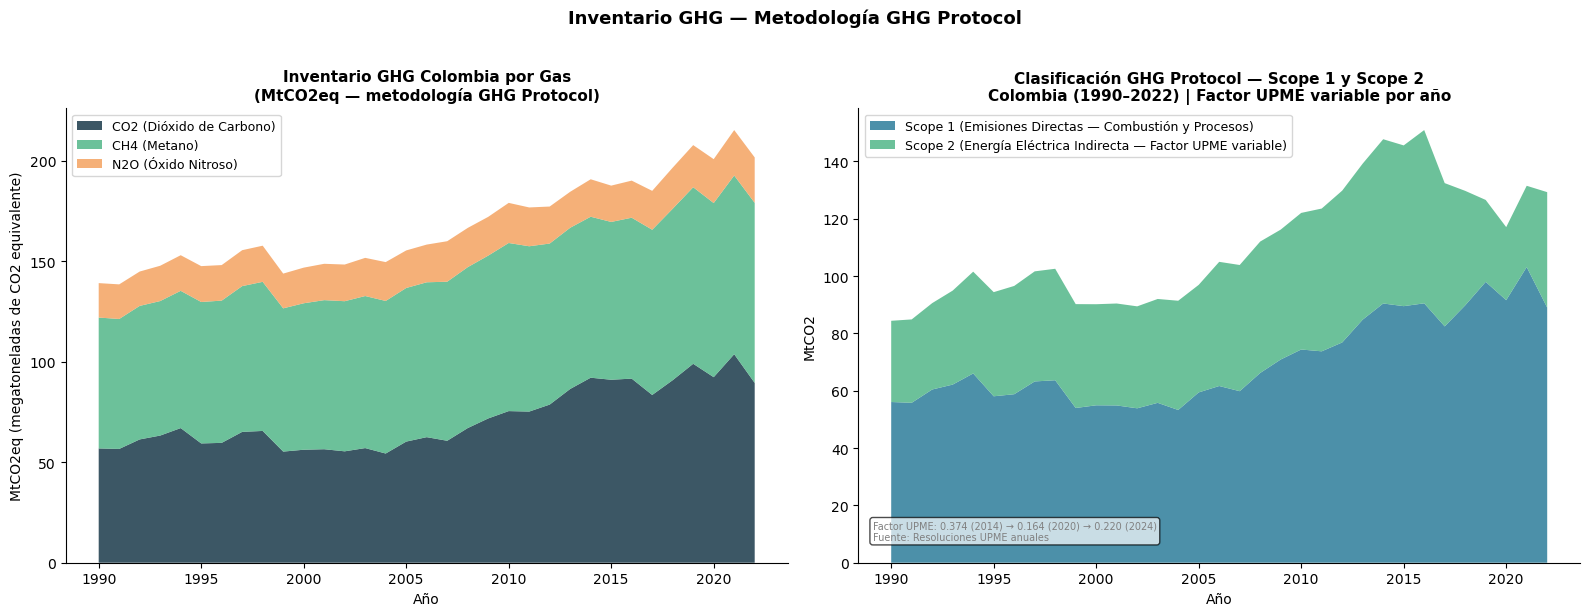

In [35]:
#  4.2 Visualización del inventario GHG por gas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Emisiones totales GHG por tipo de gas
df_ghg_plot = df_ghg.dropna(subset=['methane', 'nitrous_oxide', 'co2'])

axes[0].stackplot(
    df_ghg_plot['year'],
    df_ghg_plot['co2'],
    df_ghg_plot['methane'],
    df_ghg_plot['nitrous_oxide'],
    labels=[
        'CO2 (Dióxido de Carbono)',
        'CH4 (Metano)',
        'N2O (Óxido Nitroso)'
    ],
    colors=['#1a3a4a', '#52b788', '#f4a261'],
    alpha=0.85
)
axes[0].set_title('Inventario GHG Colombia por Gas\n(MtCO2eq — metodología GHG Protocol)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('MtCO2eq (megatoneladas de CO2 equivalente)')
axes[0].legend(fontsize=9)

# Scope 1 vs Scope 2 estimado con factor UPME variable
df_scope = df_ghg.dropna(subset=['scope1_co2', 'scope2_estimado_mtco2'])

axes[1].stackplot(
    df_scope['year'],
    df_scope['scope1_co2'],
    df_scope['scope2_estimado_mtco2'],
    labels=[
        'Scope 1 (Emisiones Directas — Combustión y Procesos)',
        'Scope 2 (Energía Eléctrica Indirecta — Factor UPME variable)'
    ],
    colors=[PALETTE['colombia'], PALETTE['verde']],
    alpha=0.85
)
axes[1].set_title('Clasificación GHG Protocol — Scope 1 y Scope 2\n'
                  'Colombia (1990–2022) | Factor UPME variable por año',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('MtCO2')
axes[1].legend(fontsize=9)

# Anotación del factor variable en el gráfico
axes[1].annotate(
    'Factor UPME: 0.374 (2014) → 0.164 (2020) → 0.220 (2024)\n'
    'Fuente: Resoluciones UPME anuales',
    xy=(0.02, 0.05), xycoords='axes fraction',
    fontsize=7, color='gray',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
)

plt.suptitle('Inventario GHG — Metodología GHG Protocol',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_inventario_ghg.png', dpi=150, bbox_inches='tight')
plt.show()

### Inventario GHG — Metodología GHG Protocol

**Gráfico izquierdo: Inventario por gas (CO2, CH4, N2O)**

El inventario GHG total de Colombia incluye tres gases principales
expresados en MtCO2eq (megatoneladas de CO2 equivalente), usando los
factores de conversión GWP (Global Warming Potential Potencial de
Calentamiento Global) del IPCC (Intergovernmental Panel on Climate
Change Panel Intergubernamental sobre Cambio Climático):

- **CO2 (Dióxido de Carbono):** la fracción más grande, proveniente
  de combustión de combustibles fósiles y procesos industriales.
- **CH4 (Metano):** segunda fuente en importancia, originada
  principalmente en ganadería, sector petrolero y rellenos sanitarios.
- **N2O (Óxido Nitroso):** componente más pequeño pero con un GWP
  298 veces mayor que el CO2  originado principalmente en agricultura
  y uso de fertilizantes nitrogenados.

El inventario total creció de aproximadamente 130 MtCO2eq en 1990
a más de 200 MtCO2eq en 2022, impulsado principalmente por CO2 y CH4.

**Gráfico derecho: Clasificación Scope 1 y Scope 2**

Bajo la metodología GHG Protocol (Greenhouse Gas Protocol Protocolo
de Gases de Efecto Invernadero):

- **Scope 1 (Emisiones Directas):** emisiones por combustión de
  carbón, petróleo, gas y procesos de cemento  la fracción dominante.
- **Scope 2 (Energía Eléctrica Indirecta):** emisiones asociadas al
  consumo de electricidad, calculadas con el factor de emisión del
  SIN (Sistema Interconectado Nacional) publicado anualmente por la
  UPME (Unidad de Planeación Minero-Energética). El factor varía entre
  0.164 tCO2eq/MWh (2020, año húmedo) y 0.374 tCO2eq/MWh (2014,
  primer factor oficial), reflejando la participación de generación
  térmica vs hidráulica en la matriz eléctrica colombiana.

---
## 5. Regresión y Proyección al 2030 NDC Colombia

Colombia se comprometió bajo el Acuerdo de París a reducir sus emisiones GHG en un **51% para 2030** respecto al escenario tendencial (BAU Business As Usual). Este análisis modela la tendencia histórica de emisiones mediante regresión lineal y proyecta el escenario BAU al 2030, comparándolo con la meta NDC para evaluar la brecha de implementación.

In [37]:
#  5.1 Regresión lineal sobre emisiones CO2 Colombia
df_reg = df_col[['year', 'co2']].dropna().copy()

X = df_reg[['year']].values
y = df_reg['co2'].values

# Modelo de regresión lineal
modelo_lineal = LinearRegression()
modelo_lineal.fit(X, y)
y_pred = modelo_lineal.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
pendiente = modelo_lineal.coef_[0]

print('REGRESIÓN LINEAL — EMISIONES CO2 COLOMBIA')
print(f'Pendiente:    {pendiente:.3f} MtCO2/año')
print(f'R²:           {r2:.4f}')
print(f'RMSE:         {rmse:.3f} MtCO2')
print()
print(f'Interpretación: Colombia aumenta en promedio {pendiente:.2f} MtCO2 por año')

# Proyección BAU al 2030
años_proyeccion = np.arange(df_reg['year'].max() + 1, 2031).reshape(-1, 1)
co2_proyectado = modelo_lineal.predict(años_proyeccion)

co2_bau_2030 = co2_proyectado[-1]
meta_ndc_2030 = co2_bau_2030 * (1 - 0.51)  # Reducción 51% vs BAU
co2_actual_2022 = df_reg[df_reg['year'] == 2022]['co2'].values[0]

print()
print('PROYECCIÓN NDC 2030')
print(f'Escenario BAU 2030:     {co2_bau_2030:.1f} MtCO2')
print(f'Meta NDC 2030 (−51%):   {meta_ndc_2030:.1f} MtCO2')
print(f'Emisiones actuales 2022: {co2_actual_2022:.1f} MtCO2')
print(f'Reducción requerida vs 2022: {co2_actual_2022 - meta_ndc_2030:.1f} MtCO2')

REGRESIÓN LINEAL — EMISIONES CO2 COLOMBIA
Pendiente:    1.350 MtCO2/año
R²:           0.7367
RMSE:         7.683 MtCO2

Interpretación: Colombia aumenta en promedio 1.35 MtCO2 por año

PROYECCIÓN NDC 2030
Escenario BAU 2030:     103.9 MtCO2
Meta NDC 2030 (−51%):   50.9 MtCO2
Emisiones actuales 2022: 89.4 MtCO2
Reducción requerida vs 2022: 38.5 MtCO2


### Regresión Lineal y Proyección NDC 2030

**Modelo de regresión lineal emisiones CO2 Colombia (1990–2022)**

| Parámetro | Valor | Interpretación |
|---|---|---|
| Pendiente | 1.35 MtCO2/año | Crecimiento promedio anual de emisiones |
| R² | 0.7367 | El modelo explica el 73.7% de la variación histórica |
| RMSE | 7.683 MtCO2 | Error promedio de la regresión — margen de incertidumbre |

**Proyección BAU (Business As Usual Tendencia sin acción adicional) vs Meta NDC**

| Escenario | MtCO2 |
|---|---|
| Escenario BAU 2030 | 103.9 |
| Meta NDC 2030 (−51% vs BAU) | 50.9 |
| Emisiones actuales 2022 | 89.4 |
| Reducción requerida vs 2022 | **38.5** |

Colombia debe reducir 38.5 MtCO2 desde los niveles de 2022 para
cumplir su NDC (Nationally Determined Contributions Contribuciones
Determinadas a Nivel Nacional) al 2030 equivalente a prácticamente
eliminar todo el sector transporte del inventario nacional en 8 años.

La brecha confirma que las políticas climáticas actuales son
insuficientes y se requieren medidas adicionales urgentes en los
sectores de mayor peso: transporte (petróleo 50%), industria
(gas 24.2%) y generación eléctrica (carbón 20.1%).

Nota: BAU (Business As Usual Tendencia sin acción adicional) es simplemente la respuesta a la pregunta: ¿qué pasaría si Colombia no hace nada diferente a lo que ya viene haciendo?

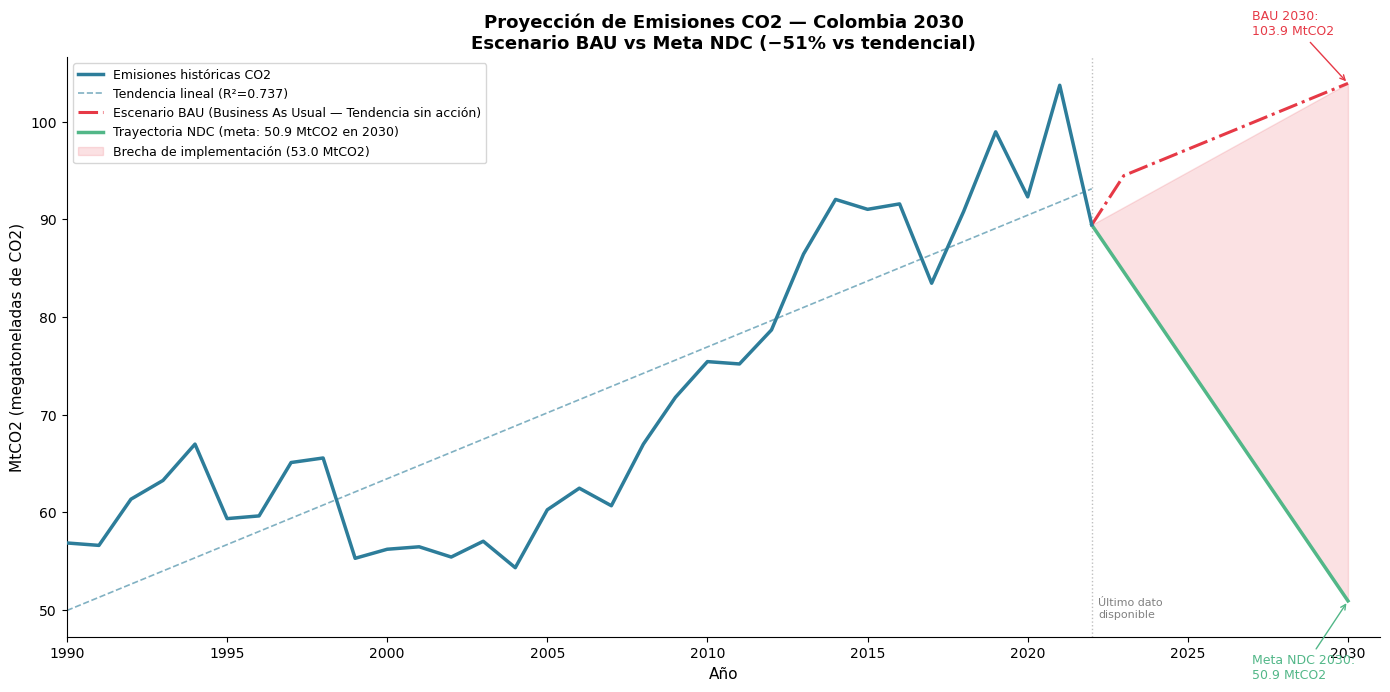

In [38]:
# --- 5.2 Visualización de proyección ---
fig, ax = plt.subplots(figsize=(14, 7))

# Datos históricos
ax.plot(df_reg['year'], df_reg['co2'],
        color=PALETTE['colombia'], linewidth=2.5,
        label='Emisiones históricas CO2', zorder=5)

# Línea de regresión histórica
ax.plot(df_reg['year'], y_pred,
        color=PALETTE['colombia'], linewidth=1.2,
        linestyle='--', alpha=0.6, label=f'Tendencia lineal (R²={r2:.3f})')

# Proyección BAU
años_hist_proy = np.append(df_reg['year'].values[-1], años_proyeccion.flatten())
co2_hist_proy = np.append(df_reg['co2'].values[-1], co2_proyectado)
ax.plot(años_hist_proy, co2_hist_proy,
        color=PALETTE['alerta'], linewidth=2.2,
        linestyle='-.', label='Escenario BAU (Business As Usual — Tendencia sin acción)')

# Meta NDC
ax.plot([df_reg['year'].max(), 2030],
        [co2_actual_2022, meta_ndc_2030],
        color=PALETTE['verde'], linewidth=2.5,
        label=f'Trayectoria NDC (meta: {meta_ndc_2030:.1f} MtCO2 en 2030)')

# Área de brecha
ax.fill_between([2022, 2030],
                [co2_actual_2022, meta_ndc_2030],
                [co2_actual_2022, co2_bau_2030],
                alpha=0.15, color=PALETTE['alerta'],
                label=f'Brecha de implementación ({co2_bau_2030 - meta_ndc_2030:.1f} MtCO2)')

# Anotaciones
ax.annotate(f'BAU 2030:\n{co2_bau_2030:.1f} MtCO2',
            xy=(2030, co2_bau_2030), xytext=(2027, co2_bau_2030 + 5),
            fontsize=9, color=PALETTE['alerta'],
            arrowprops=dict(arrowstyle='->', color=PALETTE['alerta']))

ax.annotate(f'Meta NDC 2030:\n{meta_ndc_2030:.1f} MtCO2',
            xy=(2030, meta_ndc_2030), xytext=(2027, meta_ndc_2030 - 8),
            fontsize=9, color=PALETTE['verde'],
            arrowprops=dict(arrowstyle='->', color=PALETTE['verde']))

ax.axvline(x=2022, color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax.text(2022.2, ax.get_ylim()[0] + 2, 'Último dato\ndisponible', fontsize=8, color='gray')

ax.set_title('Proyección de Emisiones CO2 — Colombia 2030\nEscenario BAU vs Meta NDC (−51% vs tendencial)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('MtCO2 (megatoneladas de CO2)', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(1990, 2031)

plt.tight_layout()
plt.savefig('fig5_proyeccion_ndc.png', dpi=150, bbox_inches='tight')
plt.show()

### Proyección de Emisiones CO2 Colombia 2030

**Escenario BAU (Business As Usual Tendencia sin acción adicional)**

La regresión lineal sobre datos históricos 1990–2022 muestra que
Colombia aumenta en promedio 1.35 MtCO2 por año (R² = 0.737).
Proyectando esta tendencia al 2030 sin políticas adicionales, el
escenario BAU alcanzaría 103.9 MtCO2.

**Meta NDC (Nationally Determined Contributions Contribuciones
Determinadas a Nivel Nacional)**

Colombia se comprometió bajo el Acuerdo de París a reducir sus
emisiones un 51% respecto al escenario BAU para 2030. Esto implica
una meta de 50.9 MtCO2 una reducción de 38.5 MtCO2 desde los
niveles actuales de 2022 (89.4 MtCO2).

**La brecha de implementación**

El área rosada en la figura representa la brecha de implementación
de 53.0 MtCO2 la distancia entre lo que Colombia emitiría sin
acción adicional y lo que se comprometió a emitir. Esta brecha
confirma que las políticas climáticas actuales son insuficientes
y se requieren medidas urgentes en:

- Transición del sector transporte: mayor fuente (50% petróleo)
- Eficiencia energética industrial: gas natural (24.2%)
- Expansión de FNCE (Fuentes No Convencionales de Energía) para
  desplazar carbón (20.1%) en generación eléctrica
- Protección de ecosistemas forestales como sumideros de carbono

### Contexto de Política Climática Colombia Estado al 2026

Colombia sí tiene políticas climáticas activas y ha fortalecido
sus compromisos recientemente, pero la velocidad de implementación
actual no es suficiente para cerrar la brecha hacia la meta NDC
(Nationally Determined Contributions. Contribuciones Determinadas
a Nivel Nacional) al 2030.

**Políticas climáticas vigentes Estado actual:**

- **Impuesto al carbono** (Ley 1819 de 2016)  tarifa actual de
  $23.000 COP/tCO2 (aproximadamente USD 7/tCO2). El DNP
  (Departamento Nacional de Planeación) estima que se requeriría
  USD 216/tCO2 para cumplir el NDC, y USD 67/tCO2 para alcanzar
  estándares OCDE.
- **Ley de Acción Climática** (Ley 2169 de 2021)  establece
  237 metas y medidas para alcanzar carbono neutralidad al 2050.
- **Sistema RE** (Sistema para la Reducción de Emisiones)  mercado
  de carbono colombiano creado con la Ley 1931 de 2018, en proceso
  de implementación.
- **NDC 3.0** (septiembre 2025)  Colombia presentó una actualización
  de sus compromisos ante la CMNUCC (Convención Marco de las Naciones
  Unidas sobre el Cambio Climático), comprometiéndose a emitir entre
  155 y 161 MtCO2eq como máximo en 2035, con una hoja de ruta con
  hitos para 2026, 2028 y 2030.
- **Expansión FNCE** (Fuentes No Convencionales de Energía) 
  proyectos eólicos en La Guajira y solares en múltiples regiones
  en desarrollo.

**Por qué las políticas actuales aún no cierran la brecha:**

El impuesto al carbono de USD 7/tCO2 es significativamente inferior
al mínimo recomendado por el FMI (Fondo Monetario Internacional)
de USD 50–100/tCO2 para generar cambios estructurales reales. El
sector transporte sigue siendo el mayor emisor (50% del total) y
la penetración de vehículos eléctricos es aún incipiente. La
deforestación en la Amazonía colombiana continúa generando emisiones
adicionales de cambio de uso del suelo no incluidas en esta figura.

La trayectoria NDC requiere bajar de 89.4 MtCO2 en 2022 a 50.9
MtCO2 en 2030 una reducción del 43% en 8 años que exige acelerar
significativamente la implementación de todas las políticas vigentes.

**Fuentes:** DNP Colombia (2023), Minambiente NDC 3.0 (2025),
WRI Colombia (2025), Ley 2169 de 2021.

---
## 6. Análisis de Correlación  Emisiones vs Desarrollo Económico

La curva de Kuznets Ambiental (EKC Environmental Kuznets Curve) postula que a medida que un país se desarrolla económicamente, sus emisiones aumentan inicialmente y luego disminuyen una vez alcanzado un umbral de ingreso. Este análisis evalúa si los países de América Latina siguen ese patrón en emisiones per cápita versus PIB per cápita.

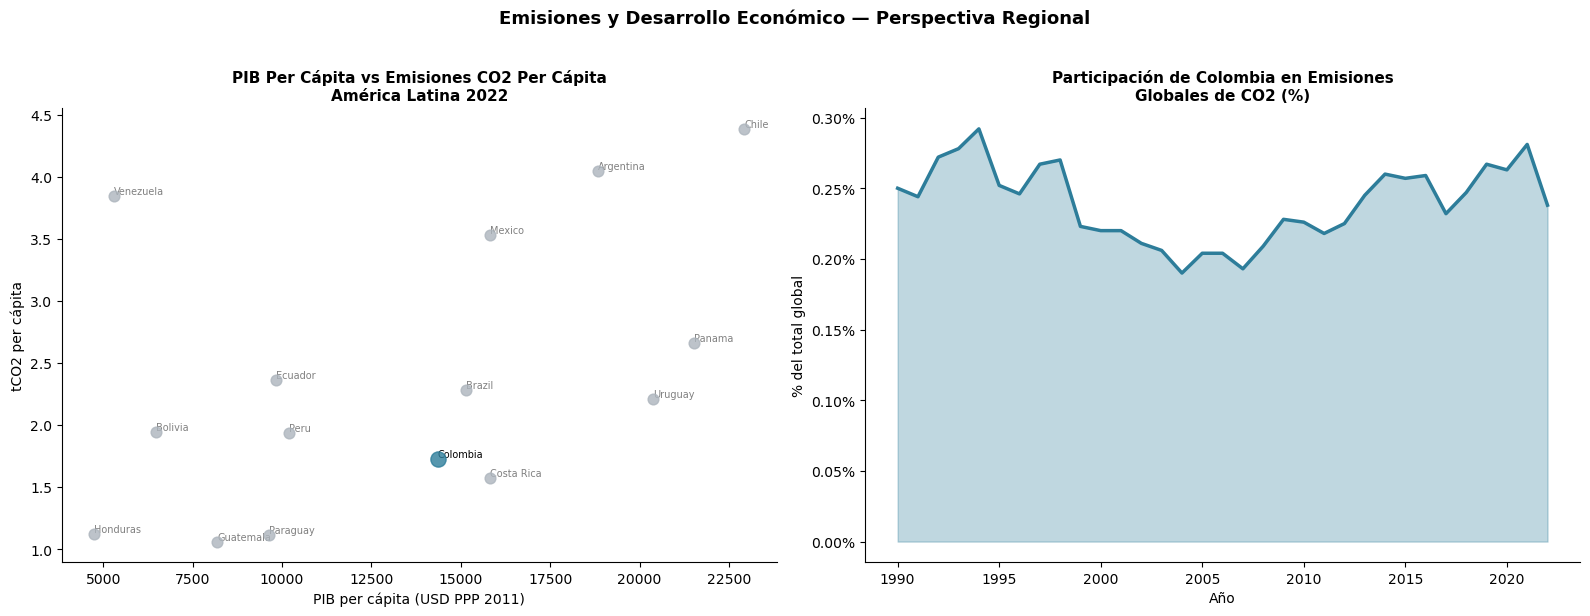

In [39]:
# --- 6.1 Emisiones vs PIB per cápita — América Latina 2022 ---
df_latam_2022 = df_latam[df_latam['year'] == 2022].copy()
df_latam_2022['gdp_per_capita'] = df_latam_2022['gdp'] / df_latam_2022['population']
df_latam_2022 = df_latam_2022.dropna(subset=['gdp_per_capita', 'co2_per_capita'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter PIB vs emisiones per cápita
for _, row in df_latam_2022.iterrows():
    color = PALETTE['colombia'] if row['country'] == 'Colombia' else PALETTE['neutro']
    size = 120 if row['country'] == 'Colombia' else 60
    axes[0].scatter(row['gdp_per_capita'], row['co2_per_capita'],
                    color=color, s=size, zorder=5, alpha=0.8)
    axes[0].annotate(row['country'],
                     (row['gdp_per_capita'], row['co2_per_capita']),
                     fontsize=7, ha='left', va='bottom',
                     color='black' if row['country'] == 'Colombia' else 'gray')

axes[0].set_title('PIB Per Cápita vs Emisiones CO2 Per Cápita\nAmérica Latina 2022',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('PIB per cápita (USD PPP 2011)')
axes[0].set_ylabel('tCO2 per cápita')

# Participación en emisiones globales — Colombia
df_col_share = df_col[['year', 'share_global_co2']].dropna()
axes[1].fill_between(df_col_share['year'], df_col_share['share_global_co2'],
                     alpha=0.3, color=PALETTE['colombia'])
axes[1].plot(df_col_share['year'], df_col_share['share_global_co2'],
             color=PALETTE['colombia'], linewidth=2.5)
axes[1].set_title('Participación de Colombia en Emisiones\nGlobales de CO2 (%)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('% del total global')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))

plt.suptitle('Emisiones y Desarrollo Económico — Perspectiva Regional',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig6_emisiones_pib.png', dpi=150, bbox_inches='tight')
plt.show()

### Emisiones y Desarrollo Económico Perspectiva Regional

**Gráfico izquierdo: PIB Per Cápita vs Emisiones CO2 Per Cápita 
América Latina 2022**

Este scatter explora la relación entre desarrollo económico y
emisiones per cápita, conocida en la literatura como la Curva de
Kuznets Ambiental (EKC Environmental Kuznets Curve), que postula
que las emisiones crecen con el ingreso hasta cierto umbral y luego
disminuyen.

En América Latina el patrón no es uniforme:

- **Chile y Argentina** lideran en emisiones per cápita (4.4 y 4.0
  tCO2/habitante) y también tienen los PIB per cápita más altos de
  la región relación positiva entre ingreso y emisiones.
- **Venezuela** presenta emisiones altas (3.8 tCO2/habitante) con
  PIB per cápita bajo, explicado por su matriz energética
  históricamente dependiente de combustibles fósiles.
- **Colombia** (punto azul) se posiciona con PIB per cápita de
  aproximadamente USD 14,000 PPP y 1.7 tCO2/habitante una de las
  mejores relaciones ingreso/emisiones de la región, gracias a su
  matriz eléctrica con alta participación hidroeléctrica.
- **Costa Rica** presenta un perfil similar a Colombia  ingreso
  medio con emisiones bajas por su transición energética avanzada.

**Gráfico derecho: Participación de Colombia en Emisiones
Globales de CO2 (%)**

Colombia representa entre el 0.20% y 0.30% de las emisiones globales
de CO2 a lo largo del período 1990–2022 una participación marginal
a escala mundial. El pico alrededor de 1994–1995 (cercano a 0.30%)
coincide con períodos de mayor actividad industrial, y la tendencia
reciente se mantiene estable alrededor de 0.25%.

Este dato refuerza el principio de equidad climática: Colombia
contribuye marginalmente al problema global pero es altamente
vulnerable a sus impactos dado su dependencia de ecosistemas
hídricos para generación eléctrica y la concentración de su
biodiversidad en zonas de alta sensibilidad climática.

---
## 7. KPIs de Sostenibilidad Resumen Ejecutivo

Los siguientes KPIs (Key Performance Indicators. Indicadores Clave de Desempeño) sintetizan el desempeño climático de Colombia en formato de reporte ESG (Environmental, Social and Governance. Ambiental, Social y de Gobernanza), alineado con los estándares GRI (Global Reporting Initiative. Iniciativa Global de Reporte) y el GHG Protocol.

In [41]:
#  7.1 Tabla de KPIs ESG para Colombia 
año_ref = 1990
año_actual = 2022

def get_val(col, año):
    vals = df_col[df_col['year'] == año][col].values
    return vals[0] if len(vals) > 0 and not np.isnan(vals[0]) else np.nan

kpis = {
    'Emisiones CO2 totales (MtCO2)': {
        '1990': round(get_val('co2', 1990), 2),
        '2022': round(get_val('co2', 2022), 2),
        'Var %': round((get_val('co2', 2022) - get_val('co2', 1990)) / get_val('co2', 1990) * 100, 1)
    },
    'Emisiones per cápita (tCO2/hab)': {
        '1990': round(get_val('co2_per_capita', 1990), 2),
        '2022': round(get_val('co2_per_capita', 2022), 2),
        'Var %': round((get_val('co2_per_capita', 2022) - get_val('co2_per_capita', 1990)) / get_val('co2_per_capita', 1990) * 100, 1)
    },
    'Intensidad carbono (kgCO2/USD PIB)': {
        '1990': round(get_val('co2_per_gdp', 1990), 4),
        '2022': round(get_val('co2_per_gdp', 2022), 4),
        'Var %': round((get_val('co2_per_gdp', 2022) - get_val('co2_per_gdp', 1990)) / get_val('co2_per_gdp', 1990) * 100, 1)
    },
    'GHG totales (MtCO2eq)': {
        '1990': round(get_val('total_ghg', 1990), 2),
        '2022': round(get_val('total_ghg', 2022), 2),
        'Var %': round((get_val('total_ghg', 2022) - get_val('total_ghg', 1990)) / get_val('total_ghg', 1990) * 100, 1)
    },
    'Participación global CO2 (%)': {
        '1990': round(get_val('share_global_co2', 1990), 3),
        '2022': round(get_val('share_global_co2', 2022), 3),
        'Var %': round((get_val('share_global_co2', 2022) - get_val('share_global_co2', 1990)) / get_val('share_global_co2', 1990) * 100, 1)
    }
}

kpi_df = pd.DataFrame(kpis).T.reset_index()
kpi_df.columns = ['Indicador', '1990', '2022', 'Variación (%)']

print('RESUMEN EJECUTIVO KPIs ESG — COLOMBIA')
print(kpi_df.to_string(index=False))
print()
print(f'Meta NDC 2030: reducir GHG en 51% vs escenario BAU')
print(f'Escenario BAU 2030 proyectado: {co2_bau_2030:.1f} MtCO2')
print(f'Meta NDC 2030: {meta_ndc_2030:.1f} MtCO2')
print(f'Brecha actual: {co2_actual_2022 - meta_ndc_2030:.1f} MtCO2 de reducción requerida')

RESUMEN EJECUTIVO KPIs ESG — COLOMBIA
                         Indicador    1990    2022  Variación (%)
     Emisiones CO2 totales (MtCO2)  56.860  89.440           57.3
   Emisiones per cápita (tCO2/hab)   1.750   1.730           -1.4
Intensidad carbono (kgCO2/USD PIB)   0.224   0.120          -46.4
             GHG totales (MtCO2eq) 155.270 237.230           52.8
      Participación global CO2 (%)   0.250   0.238           -4.8

Meta NDC 2030: reducir GHG en 51% vs escenario BAU
Escenario BAU 2030 proyectado: 103.9 MtCO2
Meta NDC 2030: 50.9 MtCO2
Brecha actual: 38.5 MtCO2 de reducción requerida


### Resumen Ejecutivo KPIs ESG Colombia 1990–2022

Los siguientes KPIs (Key Performance Indicators  Indicadores Clave de
Desempeño) sintetizan el desempeño climático de Colombia en formato de
reporte ESG (Environmental, Social and Governance Ambiental, Social
y de Gobernanza), alineado con los estándares GRI (Global Reporting
Initiative. Iniciativa Global de Reporte) y el GHG Protocol
(Greenhouse Gas Protocol. Protocolo de Gases de Efecto Invernadero).

| Indicador | 1990 | 2022 | Variación (%) |
|---|---|---|---|
| Emisiones CO2 totales (MtCO2) | 56.86 | 89.44 | +57.3% |
| Emisiones per cápita (tCO2/hab) | 1.750 | 1.730 | −1.4% |
| Intensidad de carbono (kgCO2/USD PIB) | 0.224 | 0.120 | −46.4% |
| GHG totales (MtCO2eq) | 155.27 | 237.23 | +52.8% |
| Participación global CO2 (%) | 0.250 | 0.238 | −4.8% |

**Lectura integrada de los KPIs:**

Los indicadores revelan una paradoja climática característica de
economías en desarrollo:

- Las **emisiones absolutas** crecieron 57.3%  Colombia emite más
  CO2 en términos totales que en 1990.
- Sin embargo, las **emisiones per cápita** bajaron levemente (−1.4%)
  y la **intensidad de carbono** mejoró sustancialmente (−46.4%) 
  la economía colombiana creció más eficientemente en carbono.
- La **participación global** se redujo marginalmente (−4.8%) 
  Colombia sigue siendo un emisor pequeño a escala mundial.

Esto confirma que Colombia ha desacoplado parcialmente el crecimiento
económico de las emisiones per cápita, pero no ha logrado el
desacoplamiento absoluto necesario para cumplir el Acuerdo de París

In [43]:
# 7.2 Exportación para Power BI

# Tabla principal Colombia
cols_export = [
    'year', 'co2', 'co2_per_capita', 'co2_per_gdp',
    'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2',
    'methane', 'nitrous_oxide', 'total_ghg',
    'share_global_co2', 'population', 'gdp'
]
df_col[[c for c in cols_export if c in df_col.columns]].to_csv(
    'ghg_colombia_historico.csv', index=False
)

# Tabla comparativa LATAM 2022
cols_latam = ['country', 'year', 'co2', 'co2_per_capita',
              'co2_per_gdp', 'total_ghg', 'share_global_co2']
df_latam[df_latam['year'] == 2022][[c for c in cols_latam if c in df_latam.columns]].to_csv(
    'ghg_latam_2022.csv', index=False
)

# Tabla de proyección NDC
proyeccion_df = pd.DataFrame({
    'year': años_proyeccion.flatten(),
    'co2_bau': co2_proyectado,
    'co2_ndc_meta': np.linspace(co2_actual_2022, meta_ndc_2030,
                                 len(años_proyeccion))
})
proyeccion_df.to_csv('ghg_proyeccion_ndc_2030.csv', index=False)

# Tabla de KPIs
kpi_df.to_csv('ghg_kpis_esg_colombia.csv', index=False)

print('Archivos exportados para Power BI:')
print('  ghg_colombia_historico.csv     — Serie histórica completa Colombia')
print('  ghg_latam_2022.csv             — Comparativa regional 2022')
print('  ghg_proyeccion_ndc_2030.csv    — Escenario BAU vs meta NDC')
print('  ghg_kpis_esg_colombia.csv      — KPIs resumen ejecutivo')

Archivos exportados para Power BI:
  ghg_colombia_historico.csv     — Serie histórica completa Colombia
  ghg_latam_2022.csv             — Comparativa regional 2022
  ghg_proyeccion_ndc_2030.csv    — Escenario BAU vs meta NDC
  ghg_kpis_esg_colombia.csv      — KPIs resumen ejecutivo


## 8. Conclusiones y Recomendaciones

### Hallazgos técnicos

**1. Paradoja entre eficiencia e impacto absoluto**

Las emisiones de CO2 de Colombia crecieron 57.3% entre 1990 y 2022,
impulsadas principalmente por el petróleo (Oil 50% del total) como
combustible del sector transporte, seguido por gas natural (Gas 24.2%)
y carbón (Coal 20.1%). Al mismo tiempo, la intensidad de carbono
(kgCO2 por USD de PIB Producto Interno Bruto) mejoró un 46.4%,
pasando de 0.224 a 0.120 kgCO2/USD. Esto confirma que Colombia ha
logrado un desacoplamiento parcial entre crecimiento económico y
emisiones, pero no el desacoplamiento absoluto que exige el Acuerdo
de París.

**2. Posición global y responsabilidad diferenciada**

Colombia representa entre el 0.20% y 0.25% de las emisiones globales
de CO2, posicionándose como un emisor pequeño a escala mundial. Con
1.7 tCO2 por habitante, es uno de los menores emisores per cápita
de América Latina, gracias a su matriz eléctrica con alta participación
de hidroelectricidad. Esto fundamenta el principio de equidad
climática: Colombia contribuye marginalmente al problema global pero
es altamente vulnerable a sus impactos por su dependencia de
ecosistemas hídricos y su biodiversidad estratégica.

**3. Brecha de implementación NDC al 2030**

La regresión lineal sobre datos históricos 1990–2022 (R² = 0.737,
pendiente = 1.35 MtCO2/año) proyecta un escenario BAU (Business As
Usual. Tendencia sin acción climática adicional) de 103.9 MtCO2
para 2030. La meta NDC (Nationally Determined Contributions.
Contribuciones Determinadas a Nivel Nacional) de reducción del 51%
vs BAU implica llegar a 50.9 MtCO2 una reducción de 38.5 MtCO2
desde los niveles de 2022 en solo 8 años. Las políticas vigentes,
incluyendo el impuesto al carbono de aproximadamente USD 7/tCO2,
son insuficientes para cerrar esta brecha según los análisis del DNP
(Departamento Nacional de Planeación, 2023).

**4. Actualización de compromisos NDC 3.0 (2025)**

En septiembre de 2025 Colombia presentó su NDC 3.0 ante la CMNUCC
(Convención Marco de las Naciones Unidas sobre el Cambio Climático),
comprometiéndose a emitir entre 155 y 161 MtCO2eq como máximo en
2035. Este compromiso amplía el horizonte temporal y eleva la
ambición climática, reconociendo que la crisis climática es también
social y civilizatoria, con enfoque en justicia climática y
transición justa (Minambiente, 2025).

### Recomendaciones de política climática


Acelerar la transición del sector transporte mediante incentivos a
la movilidad eléctrica, dado que el petróleo (Oil) concentra el 50%
de las emisiones totales y es la palanca de reducción de mayor impacto.

Fortalecer el sistema de MRV (Monitoring, Reporting and Verification. Monitoreo, Reporte y Verificación) de emisiones a nivel sectorial,
para identificar con precisión las palancas de reducción específicas
y hacer seguimiento al cumplimiento de las 237 metas de la Ley de
Acción Climática (Ley 2169 de 2021).

Proteger y restaurar ecosistemas forestales como sumideros de carbono
naturales, en particular la Amazonía colombiana, cuya deforestación
continua genera emisiones de cambio de uso del suelo que agravan el
inventario nacional total.

Implementar el Sistema RE (Sistema para la Reducción de Emisiones)
de mercado de carbono creado por la Ley 1931 de 2018, que actualmente
está en proceso de implementación y tiene potencial para complementar
el impuesto al carbono con mecanismos de mercado más flexibles.

### Referencias

Ritchie, H., Rosado, P. & Roser, M. (2023). CO₂ and Greenhouse Gas
Emissions. Our World in Data.
https://ourworldindata.org/co2-and-greenhouse-gas-emissions

WRI & WBCSD (2015). The Greenhouse Gas Protocol: A Corporate
Accounting and Reporting Standard. World Resources Institute.

UPME (2024). Factor de Emisión de CO2 de la Red Eléctrica Colombiana. Resolución 1198 de 2024. Unidad de Planeación Minero-Energética.

DNP (2023). Escenarios alternativos del impuesto al carbono en
Colombia. Departamento Nacional de Planeación.

Minambiente (2025). NDC 3.0 Contribución Determinada a Nivel
Nacional de Colombia. Ministerio de Ambiente y Desarrollo Sostenible.

IPCC (2022). Sixth Assessment Report. Working Group III: Mitigation
of Climate Change. Cambridge University Press.